In [16]:
import shutil
import cv2
import random
from pathlib import Path
from collections import Counter
import numpy as np
from ultralytics import YOLO
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, matthews_corrcoef

In [17]:
random.seed(42)
ROOT = Path(".")
KLSG = ROOT / "datasets" / "klsg" / "SeabedObjects-Ship-and-Airplane-dataset-master"
PULSE = ROOT / "datasets" / "marine_pulse"
PREPROCESSED = ROOT / "datasets" / "preprocessed"

In [18]:
all_files = []

ship_files = [f for f in (list(KLSG.glob("ship*.png")) + list(KLSG.glob("ship*.jpg"))) if not is_dropped(f)]
all_files += [(f, "ship") for f in ship_files]

plane_files = [f for f in (list((KLSG / "plane-real").glob("*.png")) + list((KLSG / "plane-real").glob("*.jpg"))) if not is_dropped(f)]
all_files += [(f, "airplane") for f in plane_files]

name_map = {
    "pipeline or cable": "pipeline_or_cable",
    "engineering platform": "engineering_platform",
    "seabed surface": "seabed_surface",
}
for src_split in ["train", "test"]:
    split_dir = PULSE / src_split
    if not split_dir.exists():
        continue
    for class_folder in split_dir.iterdir():
        if class_folder.is_dir() and class_folder.name in name_map:
            imgs = [f for f in (list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.png"))) if not is_dropped(f)]
            all_files += [(f, name_map[class_folder.name]) for f in imgs]

print(f"Total usable images: {len(all_files)}")
print(Counter(label for _, label in all_files))

Total usable images: 940
Counter({'ship': 385, 'pipeline_or_cable': 323, 'seabed_surface': 88, 'engineering_platform': 82, 'airplane': 62})


In [19]:
def preprocess_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    denoised = cv2.fastNlMeansDenoising(img, h=10, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    return enhanced

In [20]:
if PREPROCESSED.exists():
    shutil.rmtree(PREPROCESSED)
PREPROCESSED.mkdir(parents=True, exist_ok=True)

new_all_files = []
for path, label in all_files:
    processed = preprocess_image(path)
    dest_dir = PREPROCESSED / label
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / path.name
    cv2.imwrite(str(dest_path), processed)
    new_all_files.append((dest_path, label))

all_files = new_all_files
print(f"Preprocessed {len(all_files)} images -> {PREPROCESSED}")

Preprocessed 940 images -> datasets\preprocessed


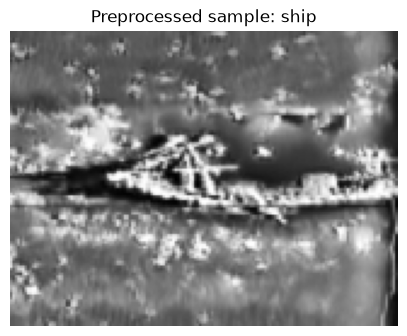

In [21]:
import matplotlib.pyplot as plt

sample_path, sample_label = all_files[0]
img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Preprocessed sample: {sample_label}")
plt.axis("off")
plt.show()

In [22]:
paths = [f for f, _ in all_files]
labels = [l for _, l in all_files]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(paths, labels))
print(f"Created {len(folds)} folds")

Created 5 folds


In [23]:
def build_fold_dirs(fold_idx, train_idx, test_idx):
    fold_root = Path(f"datasets/cv_fold_{fold_idx}")
    if fold_root.exists():
        shutil.rmtree(fold_root)
    for split_name, idx_list in [("train", train_idx), ("val", test_idx)]:
        for i in idx_list:
            path, label = paths[i], labels[i]
            dest_dir = fold_root / split_name / label
            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(path, dest_dir / path.name)
    return fold_root

In [24]:
fold_results = []

for fold_idx, (train_idx, test_idx) in enumerate(folds):
    print(f"\n=== Fold {fold_idx+1}/5 ===")
    fold_root = build_fold_dirs(fold_idx, train_idx, test_idx)

    model = YOLO("yolov8n-cls.pt")
    model.train(data=str(fold_root), epochs=20, imgsz=224, device=0,
                project="runs_cv", name=f"fold_{fold_idx}", verbose=False)

    test_files = [paths[i] for i in test_idx]
    true_labels = [labels[i] for i in test_idx]
    preds = model.predict(source=[str(p) for p in test_files], verbose=False)
    pred_labels = [p.names[p.probs.top1] for p in preds]

    acc = accuracy_score(true_labels, pred_labels)
    mcc = matthews_corrcoef(true_labels, pred_labels)
    fold_results.append({"fold": fold_idx, "accuracy": acc, "mcc": mcc})
    print(f"Fold {fold_idx+1}: accuracy={acc:.3f}, MCC={mcc:.3f}")


=== Fold 1/5 ===
Ultralytics 8.4.148  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\cv_fold_0, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fold_0, nbs=6

In [25]:
accs = [r["accuracy"] for r in fold_results]
mccs = [r["mcc"] for r in fold_results]
print(f"Mean accuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Mean MCC:      {np.mean(mccs):.3f} ± {np.std(mccs):.3f}")

Mean accuracy: 0.964 ± 0.019
Mean MCC:      0.948 ± 0.027


In [26]:
fold_paths = []
for i in range(5):
    matches = sorted(Path("runs/classify/runs_cv").glob(f"fold_{i}*"), key=lambda p: p.stat().st_mtime)
    weights = matches[-1] / "weights" / "best.pt"
    fold_dir = Path(f"datasets/cv_fold_{i}")
    fold_paths.append({"fold": i, "weights": weights, "dir": fold_dir})
    print(i, weights, weights.exists())

0 runs\classify\runs_cv\fold_0\weights\best.pt True
1 runs\classify\runs_cv\fold_1\weights\best.pt True
2 runs\classify\runs_cv\fold_2\weights\best.pt True
3 runs\classify\runs_cv\fold_3\weights\best.pt True
4 runs\classify\runs_cv\fold_4\weights\best.pt True


In [27]:
from sklearn.metrics import confusion_matrix

detailed_results = []
all_true, all_pred = [], []

for fp in fold_paths:
    model = YOLO(fp["weights"])

    # Training accuracy: predict on this fold's own training images
    train_files, train_true = [], []
    for class_dir in (fp["dir"] / "train").iterdir():
        for f in class_dir.glob("*"):
            train_files.append(str(f))
            train_true.append(class_dir.name)
    train_preds = model.predict(source=train_files, verbose=False)
    train_pred_labels = [p.names[p.probs.top1] for p in train_preds]
    train_acc = accuracy_score(train_true, train_pred_labels)

    # Test accuracy: predict on this fold's held-out val images
    val_files, val_true = [], []
    for class_dir in (fp["dir"] / "val").iterdir():
        for f in class_dir.glob("*"):
            val_files.append(str(f))
            val_true.append(class_dir.name)
    val_preds = model.predict(source=val_files, verbose=False)
    val_pred_labels = [p.names[p.probs.top1] for p in val_preds]
    val_acc = accuracy_score(val_true, val_pred_labels)
    val_mcc = matthews_corrcoef(val_true, val_pred_labels)

    all_true += val_true
    all_pred += val_pred_labels

    detailed_results.append({
        "fold": fp["fold"], "train_acc": train_acc, "test_acc": val_acc, "test_mcc": val_mcc
    })
    print(f"Fold {fp['fold']}: train_acc={train_acc:.3f}  test_acc={val_acc:.3f}  test_MCC={val_mcc:.3f}")

Fold 0: train_acc=1.000  test_acc=0.963  test_MCC=0.946
Fold 1: train_acc=0.989  test_acc=0.931  test_MCC=0.901
Fold 2: train_acc=0.999  test_acc=0.973  test_MCC=0.962
Fold 3: train_acc=0.999  test_acc=0.963  test_MCC=0.947
Fold 4: train_acc=0.995  test_acc=0.989  test_MCC=0.985


In [28]:
print(f"{'Fold':<6}{'Train Acc':<12}{'Test Acc':<12}{'Test MCC':<10}")
for r in detailed_results:
    print(f"{r['fold']:<6}{r['train_acc']:<12.3f}{r['test_acc']:<12.3f}{r['test_mcc']:<10.3f}")

train_accs = [r["train_acc"] for r in detailed_results]
test_accs = [r["test_acc"] for r in detailed_results]
test_mccs = [r["test_mcc"] for r in detailed_results]
print(f"\nMean train accuracy: {np.mean(train_accs):.3f}")
print(f"Mean test accuracy:  {np.mean(test_accs):.3f} ± {np.std(test_accs):.3f}")
print(f"Mean test MCC:       {np.mean(test_mccs):.3f} ± {np.std(test_mccs):.3f}")

Fold  Train Acc   Test Acc    Test MCC  
0     1.000       0.963       0.946     
1     0.989       0.931       0.901     
2     0.999       0.973       0.962     
3     0.999       0.963       0.947     
4     0.995       0.989       0.985     

Mean train accuracy: 0.996
Mean test accuracy:  0.964 ± 0.019
Mean test MCC:       0.948 ± 0.027


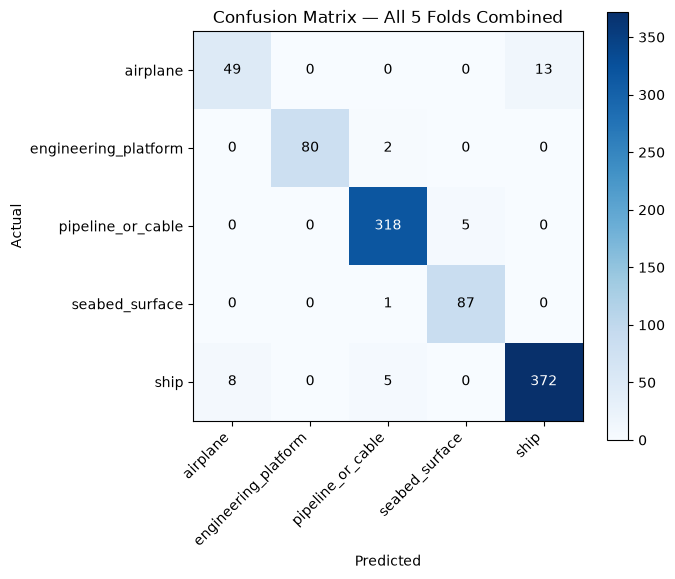

In [29]:
class_names = sorted(set(all_true))
cm = confusion_matrix(all_true, all_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — All 5 Folds Combined")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

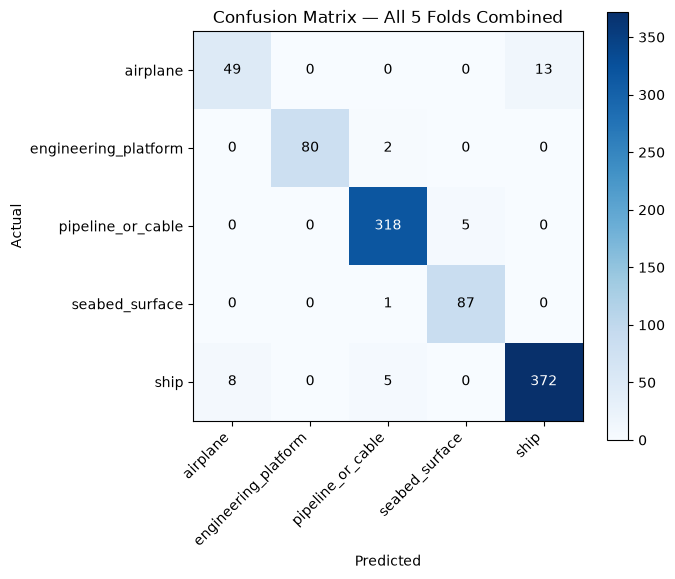

Saved: confusion_matrix_final.png


In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — All 5 Folds Combined")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix_final.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_final.png")

In [31]:
with open("results_summary.txt", "w") as f:
    f.write(f"{'Fold':<6}{'Train Acc':<12}{'Test Acc':<12}{'Test MCC':<10}\n")
    for r in detailed_results:
        f.write(f"{r['fold']:<6}{r['train_acc']:<12.3f}{r['test_acc']:<12.3f}{r['test_mcc']:<10.3f}\n")
    f.write(f"\nMean train accuracy: {np.mean(train_accs):.3f}\n")
    f.write(f"Mean test accuracy:  {np.mean(test_accs):.3f} ± {np.std(test_accs):.3f}\n")
    f.write(f"Mean test MCC:       {np.mean(test_mccs):.3f} ± {np.std(test_mccs):.3f}\n")
print("Saved: results_summary.txt")

Saved: results_summary.txt
